# 03 — TF-IDF + Logistic Regression

This notebook trains and validates the classical sentiment baseline.
the notebook orchestrates the experiment, displays results, and saves artifacts.

In [1]:
# locate the project root
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root")

PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd

from src.config import (
    CLEANED_REVIEWS_PATH,
    SENTIMENT_LABELS,
    REPORTS_DIR,
    TFIDF_LOGISTIC_CONFUSION_MATRIX_CSV_PATH,
    TFIDF_LOGISTIC_CONFUSION_MATRIX_PATH,
    TFIDF_LOGISTIC_METRICS_PATH,
    TFIDF_LOGISTIC_MODEL_PATH,
    TFIDF_LOGISTIC_REPORT_PATH,
    TFIDF_LOGISTIC_RESULT_PATH,
    TFIDF_LOGISTIC_TOP_FEATURES_PATH,
    create_project_directories,
)
from src.data.evaluation import (
    combine_top_features,
    create_model_result_row,
    display_top_features_per_class,
    evaluate_model,
    get_top_features_per_class,
)
from src.data.load import load_csv
from src.model_io import save_dataframe, save_metrics, save_model
from src.sentiment.data import prepare_classical_sentiment_data, split_sentiment_data
from src.sentiment.tfidf_logistic import build_tfidf_logistic_pipeline
from src.tracker import log_experiment

create_project_directories()

In [3]:
# Load the processed dataset
df = load_csv(CLEANED_REVIEWS_PATH)
df.head()

INFO - Loaded 47279 rows


,product_name,asins,brand,categories,review_date,rating,review_text,review_title,source_dataset,primary_categories,sentiment_label,normalized_combined_text,transformer_text,classical_text
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",2017-01-13 00:00:00+00:00,5,This product so far has not disappointed. My c...,Kindle,cleaned_reviews,NaN,positive,Kindle This product so far has not disappointe...,Kindle This product so far has not disappointe...,kindle product far not disappointed child love...
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",2017-01-13 00:00:00+00:00,5,great for beginner or experienced person. Boug...,very fast,cleaned_reviews,NaN,positive,very fast great for beginner or experienced pe...,very fast great for beginner or experienced pe...,fast great beginner experienced person bought ...
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",2017-01-13 00:00:00+00:00,5,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,cleaned_reviews,NaN,positive,Beginner tablet for our 9 year old son. Inexpe...,Beginner tablet for our 9 year old son. Inexpe...,beginner tablet year old son inexpensive table...
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",2017-01-13 00:00:00+00:00,4,I've had my Fire HD 8 two weeks now and I love...,Good!!!,cleaned_reviews,NaN,positive,Good!!! I've had my Fire HD 8 two weeks now an...,Good!!! I've had my Fire HD 8 two weeks now an...,good fire hd two week love tablet great value ...
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",2017-01-12 00:00:00+00:00,5,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,cleaned_reviews,NaN,positive,Fantastic Tablet for kids I bought this for my...,Fantastic Tablet for kids I bought this for my...,fantastic tablet kid bought grand daughter com...


In [4]:
# preparing the model dataset by validating the required columns and removes rows with missing or empty `classical_text`.
model_df = prepare_classical_sentiment_data(df)

print(f"Model dataset shape: {model_df.shape}")
model_df.head()

Model dataset shape: (47276, 2)


,classical_text,sentiment_label
0,kindle product far not disappointed child love...,positive
1,fast great beginner experienced person bought ...,positive
2,beginner tablet year old son inexpensive table...,positive
3,good fire hd two week love tablet great value ...,positive
4,fantastic tablet kid bought grand daughter com...,positive


In [5]:
# Inspect class distribution
class_counts = model_df["sentiment_label"].value_counts()
class_percentages = (
    model_df["sentiment_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages,
})

display(class_summary)

,count,percentage
sentiment_label,,
positive,43363,91.72
neutral,2072,4.38
negative,1841,3.89


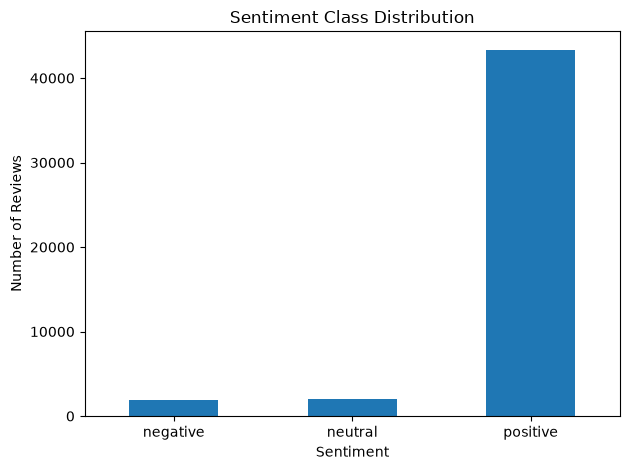

In [6]:
class_counts.reindex(SENTIMENT_LABELS).plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Create stratified train, validation, and test sets. The test set remains untouched until the final model has been selected.
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
) = split_sentiment_data(model_df)

print(f"Training rows:   {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Test rows:       {len(X_test)}")

Training rows:   30256
Validation rows: 7564
Test rows:       9456


In [8]:
split_summary = pd.concat(
    [
        y_train.value_counts(normalize=True).mul(100).rename("train"),
        y_val.value_counts(normalize=True).mul(100).rename("validation"),
        y_test.value_counts(normalize=True).mul(100).rename("test"),
    ],
    axis=1,
).reindex(SENTIMENT_LABELS).round(2)

display(split_summary)

,train,validation,test
sentiment_label,,,
negative,3.89,3.90,3.89
neutral,4.38,4.38,4.39
positive,91.72,91.72,91.72


In [9]:
#  Build and train the baseline model. The pipeline definition lives in `src/sentiment/tfidf_logistic.py`.
baseline_pipeline = build_tfidf_logistic_pipeline()
baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.95
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",30000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [10]:
training_start = perf_counter()
baseline_pipeline.fit(X_train, y_train)
training_time_seconds = perf_counter() - training_start

print(f"Training completed in {training_time_seconds:.2f} seconds.")

Training completed in 3.25 seconds.


Evaluating: TF-IDF Logistic Regression
Classification metrics
------------------------------
Accuracy: 0.9028
Macro Precision: 0.6128
Macro Recall: 0.7342
Macro F1: 0.6575
Weighted F1: 0.9154
Average inference per review: 0.0374 ms


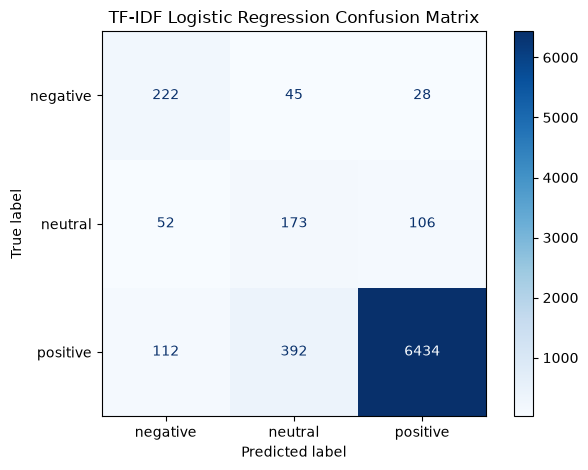

In [11]:
# Evaluate on the validation set
validation_results = evaluate_model(
    model=baseline_pipeline,
    X=X_val,
    y_true=y_val,
    model_name="TF-IDF Logistic Regression",
    labels=SENTIMENT_LABELS,
    confusion_matrix_path=TFIDF_LOGISTIC_CONFUSION_MATRIX_PATH,
)

In [12]:
display(validation_results["classification_report"])

,precision,recall,f1-score,support
negative,0.575130,0.752542,0.651982,295.000000
neutral,0.283607,0.522659,0.367694,331.000000
positive,0.979598,0.927357,0.952762,6938.000000
accuracy,0.902829,0.902829,0.902829,0.902829
macro avg,0.612778,0.734186,0.657479,7564.000000
weighted avg,0.933367,0.902829,0.915429,7564.000000


In [13]:
# Inspect the most influential TF-IDF features
top_features = get_top_features_per_class(
    pipeline=baseline_pipeline,
    top_n=15,
)

display_top_features_per_class(top_features)


Top features for: negative
----------------------------------------
     feature  coefficient
    one star     6.250194
    two star     5.122793
         not     4.995768
        dead     4.447901
    returned     4.026126
        poor     3.718000
disappointed     3.587009
        week     3.355662
   not worth     3.211223
         day     3.033588
        slow     2.990266
    not good     2.912113
        junk     2.882531
       waste     2.756804
       worst     2.641193

Top features for: neutral
----------------------------------------
      feature  coefficient
   three star     6.431629
           ok     4.894969
        three     4.671440
         good     3.467474
      however     2.978584
       decent     2.876551
     one love     2.577175
bought travel     2.513496
         okay     2.446933
         fine     2.358466
     mediocre     2.303063
    first one     2.251477
     not easy     2.224084
     beginner     2.200387
  use product     2.184556

Top features f

In [ ]:
# Save the validation result and fitted pipeline
experiment_result = create_model_result_row(
    model_name="tfidf_logistic_regression",
    metrics=validation_results["metrics"],
    training_time_seconds=training_time_seconds,
    inference_time_ms=validation_results["inference"]["average_inference_ms"],
)
experiment_result.insert(1, "imbalance_strategy", "class_weight_balanced")
experiment_result.insert(2, "train_rows", len(X_train))
experiment_result.insert(3, "validation_rows", len(X_val))

top_features_df = combine_top_features(top_features)

saved_model_path = save_model(baseline_pipeline, TFIDF_LOGISTIC_MODEL_PATH)
save_metrics(validation_results["metrics"], TFIDF_LOGISTIC_METRICS_PATH)
save_dataframe(validation_results["classification_report"], TFIDF_LOGISTIC_REPORT_PATH, index=True)
save_dataframe(validation_results["confusion_matrix"], TFIDF_LOGISTIC_CONFUSION_MATRIX_CSV_PATH, index=True)
save_dataframe(experiment_result, TFIDF_LOGISTIC_RESULT_PATH)
save_dataframe(top_features_df, TFIDF_LOGISTIC_TOP_FEATURES_PATH)

logged_row = log_experiment(
    model_name="tfidf_logistic_regression",
    dataset=CLEANED_REVIEWS_PATH.name,
    training_rows=len(X_train),
    validation_rows=len(X_val),
    metrics=validation_results["metrics"],
    training_time_seconds=training_time_seconds,
    inference_time_ms=validation_results["inference"]["average_inference_ms"],
    artifact_path=saved_model_path,
    hyperparameters=baseline_pipeline.get_params(),
)

display(experiment_result)
display(logged_row)
print(f"Saved model:              {saved_model_path}")
print(f"Saved metrics:            {TFIDF_LOGISTIC_METRICS_PATH}")
print(f"Saved report:             {TFIDF_LOGISTIC_REPORT_PATH}")
print(f"Saved confusion matrix:   {TFIDF_LOGISTIC_CONFUSION_MATRIX_PATH}")
print(f"Saved matrix values:      {TFIDF_LOGISTIC_CONFUSION_MATRIX_CSV_PATH}")
print(f"Saved top features:       {TFIDF_LOGISTIC_TOP_FEATURES_PATH}")


TypeError: Object of type LogisticRegression is not JSON serializable

## Next step

Do not evaluate the test set yet. Use the validation results to compare this baseline with the other candidate models. Evaluate the final selected model once on `X_test` and `y_test`.